# Pairs Trading & Statistical Arbitrage
### By: Amartiya Kakodiya | IIT Kharagpur

## Overview
This project implements a pairs trading strategy based on 
statistical arbitrage. We identify cointegrated stock pairs 
using the Engle-Granger cointegration test and ADF stationarity 
checks. We then build z-score based entry/exit signals on the 
spread and backtest the strategy computing Sharpe ratio and 
max drawdown.

## Methodology
1. Simulate cointegrated stock pair with common stochastic trend
2. Run ADF test to confirm non-stationarity of individual series
3. Run Engle-Granger cointegration test on the pair
4. Compute hedge ratio via OLS regression
5. Build z-score based entry/exit signals
6. Backtest strategy and compute performance metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, coint
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Step 1 — Stock Price Data
We simulate two cointegrated stocks sharing a common 
stochastic trend — mimicking real world pairs like 
Coca Cola/Pepsi or Gold ETFs. Each stock follows the 
common trend with added noise creating temporary 
divergences that the strategy exploits.

Data simulated successfully
Total trading days: 753

              Stock_A    Stock_B
2023-11-15  37.715753  22.168611
2023-11-16  36.175585  22.132627
2023-11-17  35.659764  21.840314
2023-11-20  34.224674  20.375479
2023-11-21  33.107279  18.698229


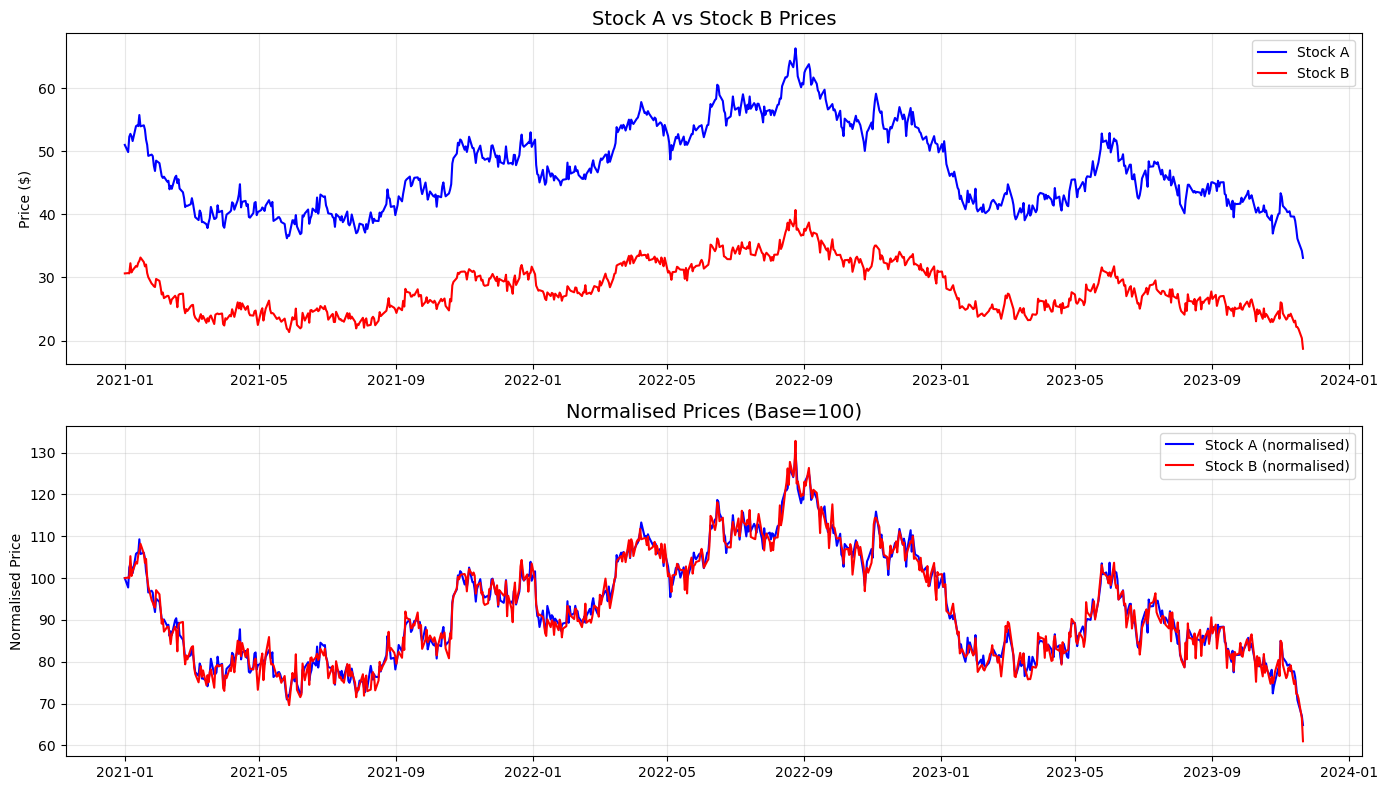

Stock prices plotted successfully


In [25]:
# Simulate a cointegrated pair directly
np.random.seed(42)
n = 753  # same number of trading days

# Common stochastic trend
common_trend = np.cumsum(np.random.randn(n))

# Stock 1 and Stock 2 follow the same trend with noise
stock1 = 50 + common_trend + np.random.randn(n) * 0.5
stock2 = 30 + 0.6 * common_trend + np.random.randn(n) * 0.5

# Create dataframe
dates = pd.date_range(start="2021-01-01", periods=n, freq="B")
df = pd.DataFrame({
    "Stock_A": stock1,
    "Stock_B": stock2
}, index=dates)

ticker1 = "Stock_A"
ticker2 = "Stock_B"

print(f"Data simulated successfully")
print(f"Total trading days: {len(df)}")
print(f"\n{df.tail(5)}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df[ticker1], color="blue", linewidth=1.5, label="Stock A")
axes[0].plot(df[ticker2], color="red", linewidth=1.5, label="Stock B")
axes[0].set_title("Stock A vs Stock B Prices", fontsize=14)
axes[0].set_ylabel("Price ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df[ticker1]/df[ticker1].iloc[0]*100, color="blue", linewidth=1.5, label="Stock A (normalised)")
axes[1].plot(df[ticker2]/df[ticker2].iloc[0]*100, color="red", linewidth=1.5, label="Stock B (normalised)")
axes[1].set_title("Normalised Prices (Base=100)", fontsize=14)
axes[1].set_ylabel("Normalised Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("stock_prices.png", dpi=150)
plt.show()
print("Stock prices plotted successfully")

## Step 2 — ADF Test & Cointegration Test
Two key statistical tests:

**ADF Test (Augmented Dickey-Fuller):**
Tests if each individual price series is stationary.
For pairs trading we need both series to be NON-stationary
individually but their spread to be stationary.

**Engle-Granger Cointegration Test:**
Tests if a linear combination of the two series is stationary.
P-value < 0.05 confirms cointegration — the pair has a 
stable long run relationship we can trade around.

**Hedge Ratio (OLS):**
Computed via OLS regression — tells us how many units of 
Stock B to short for every unit of Stock A we buy.

  STEP 1 — ADF STATIONARITY TEST
  ADF Test — Stock_A
  ADF Statistic:  -1.5883
  P-Value:        0.4894
  Result:         Non-Stationary ✗

  ADF Test — Stock_B
  ADF Statistic:  -1.6322
  P-Value:        0.4663
  Result:         Non-Stationary ✗

  STEP 2 — ENGLE-GRANGER COINTEGRATION TEST
  Cointegration Score:  -26.9776
  P-Value:              0.0000
  Result:               Cointegrated ✓

  STEP 3 — HEDGE RATIO (OLS REGRESSION)
  Hedge Ratio (beta):   1.6314
  Intercept:            1.0528
  R-Squared:            0.9789



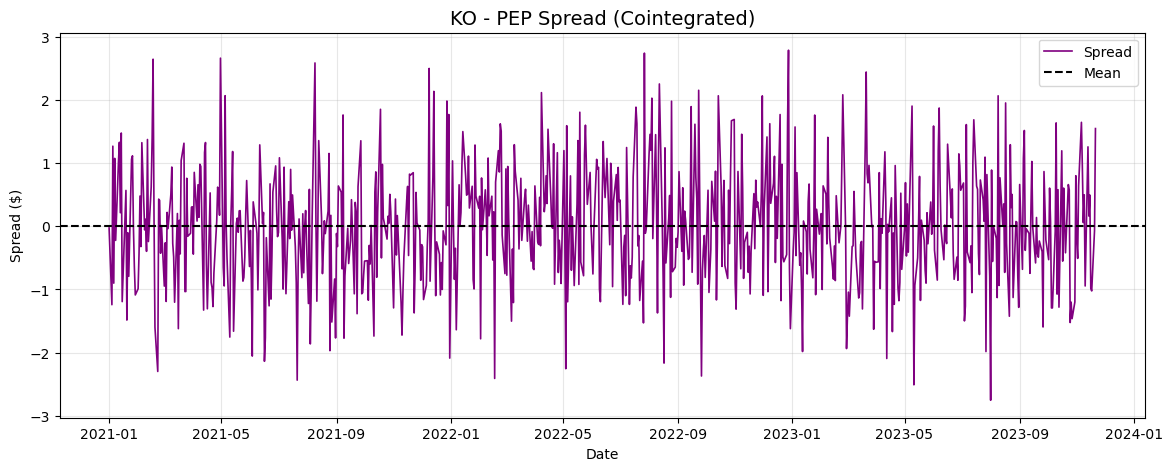

Spread plotted successfully


In [27]:
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── ADF Stationarity Test ──────────────────────────────
def adf_test(series, name):
    result = adfuller(series)
    print(f"  ADF Test — {name}")
    print(f"  ADF Statistic:  {result[0]:.4f}")
    print(f"  P-Value:        {result[1]:.4f}")
    print(f"  Result:         {'Non-Stationary ✗' if result[1] > 0.05 else 'Stationary ✓'}")
    print()

print("=" * 50)
print("  STEP 1 — ADF STATIONARITY TEST")
print("=" * 50)
adf_test(df[ticker1], ticker1)
adf_test(df[ticker2], ticker2)

# ── Cointegration Test ─────────────────────────────────
print("=" * 50)
print("  STEP 2 — ENGLE-GRANGER COINTEGRATION TEST")
print("=" * 50)
score, pvalue, _ = coint(df[ticker1], df[ticker2])
print(f"  Cointegration Score:  {score:.4f}")
print(f"  P-Value:              {pvalue:.4f}")
print(f"  Result:               {'Cointegrated ✓' if pvalue < 0.05 else 'Not Cointegrated ✗'}")
print()

# ── Hedge Ratio via OLS ────────────────────────────────
print("=" * 50)
print("  STEP 3 — HEDGE RATIO (OLS REGRESSION)")
print("=" * 50)
X = add_constant(df[ticker2])
model = OLS(df[ticker1], X).fit()
hedge_ratio = model.params[ticker2]
intercept   = model.params["const"]
print(f"  Hedge Ratio (beta):   {hedge_ratio:.4f}")
print(f"  Intercept:            {intercept:.4f}")
print(f"  R-Squared:            {model.rsquared:.4f}")
print()

# ── Compute Spread ─────────────────────────────────────
df["Spread"] = df[ticker1] - hedge_ratio * df[ticker2] - intercept

# Plot spread
plt.figure(figsize=(14, 5))
plt.plot(df["Spread"], color="purple", linewidth=1.2, label="Spread")
plt.axhline(y=df["Spread"].mean(), color="black", linestyle="--", linewidth=1.5, label="Mean")
plt.title("KO - PEP Spread (Cointegrated)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Spread ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("spread.png", dpi=150)
plt.show()
print("Spread plotted successfully")

## Step 3 — Z-Score & Trading Signals
We compute a rolling z-score of the spread:

z = (Spread - Rolling Mean) / Rolling Std

Trading rules:
- Z-Score > +2.0 → Short the spread (convergence expected)
- Z-Score < -2.0 → Long the spread (convergence expected)  
- |Z-Score| < 0.5 → Exit position (spread has mean reverted)

The z-score normalises the spread making signals 
comparable across different market regimes.

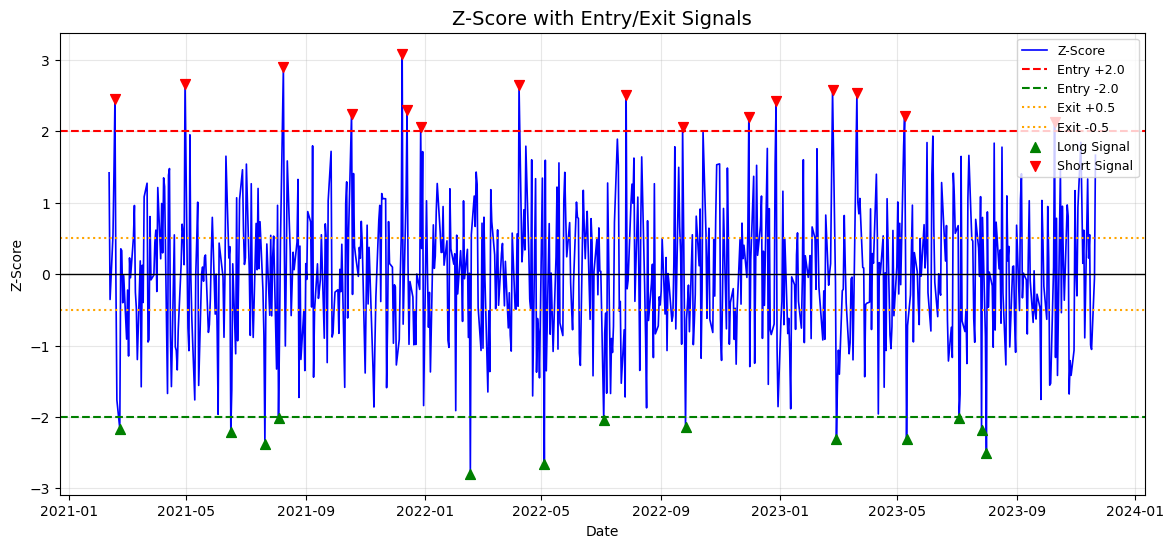

Total Long  Signals: 13
Total Short Signals: 16
Total Exit  Signals: 695


In [29]:
# Compute rolling z-score of spread
window = 30  # 30 day rolling window

df["Spread_Mean"] = df["Spread"].rolling(window).mean()
df["Spread_Std"]  = df["Spread"].rolling(window).std()
df["Z_Score"]     = (df["Spread"] - df["Spread_Mean"]) / df["Spread_Std"]

# Drop NaN values from rolling window
df = df.dropna()

# Entry/Exit thresholds
entry_threshold = 2.0   # enter when z-score exceeds 2
exit_threshold  = 0.5   # exit when z-score returns to 0.5

# Generate signals
df["Signal"] = 0
df.loc[df["Z_Score"] >  entry_threshold, "Signal"] = -1  # short spread
df.loc[df["Z_Score"] < -entry_threshold, "Signal"] =  1  # long spread
df.loc[abs(df["Z_Score"]) < exit_threshold, "Signal"] = 0  # exit

# Plot Z-Score with signals
plt.figure(figsize=(14, 6))
plt.plot(df["Z_Score"], color="blue", linewidth=1.2, label="Z-Score")
plt.axhline(y=entry_threshold,  color="red",   linestyle="--", linewidth=1.5, label=f"Entry +{entry_threshold}")
plt.axhline(y=-entry_threshold, color="green", linestyle="--", linewidth=1.5, label=f"Entry -{entry_threshold}")
plt.axhline(y=exit_threshold,   color="orange",linestyle=":",  linewidth=1.5, label=f"Exit +{exit_threshold}")
plt.axhline(y=-exit_threshold,  color="orange",linestyle=":",  linewidth=1.5, label=f"Exit -{exit_threshold}")
plt.axhline(y=0, color="black", linestyle="-", linewidth=1)

# Mark entry points
plt.scatter(df.index[df["Signal"] ==  1], df["Z_Score"][df["Signal"] ==  1],
            color="green", marker="^", s=50, zorder=5, label="Long Signal")
plt.scatter(df.index[df["Signal"] == -1], df["Z_Score"][df["Signal"] == -1],
            color="red", marker="v", s=50, zorder=5, label="Short Signal")

plt.title("Z-Score with Entry/Exit Signals", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.savefig("zscore_signals.png", dpi=150)
plt.show()

print(f"Total Long  Signals: {(df['Signal'] == 1).sum()}")
print(f"Total Short Signals: {(df['Signal'] == -1).sum()}")
print(f"Total Exit  Signals: {(df['Signal'] == 0).sum()}")

## Step 4 — Backtest & Performance Analysis
We backtest the strategy on 753 trading days with 
$100,000 starting capital. At each signal:
- Long signal → buy spread (long Stock A, short Stock B)
- Short signal → sell spread (short Stock A, long Stock B)
- Exit signal → close position and book P&L

Performance metrics computed:
- Total Return — overall strategy profitability
- Sharpe Ratio — risk adjusted return
- Max Drawdown — worst peak to trough loss

   PAIRS TRADING BACKTEST RESULTS
  Starting Capital:   $100,000
  Final Capital:      $101,134.33
  Total Return:       1.13%
  Sharpe Ratio:       0.3801
  Max Drawdown:       -0.59%
  Total Trades:       28


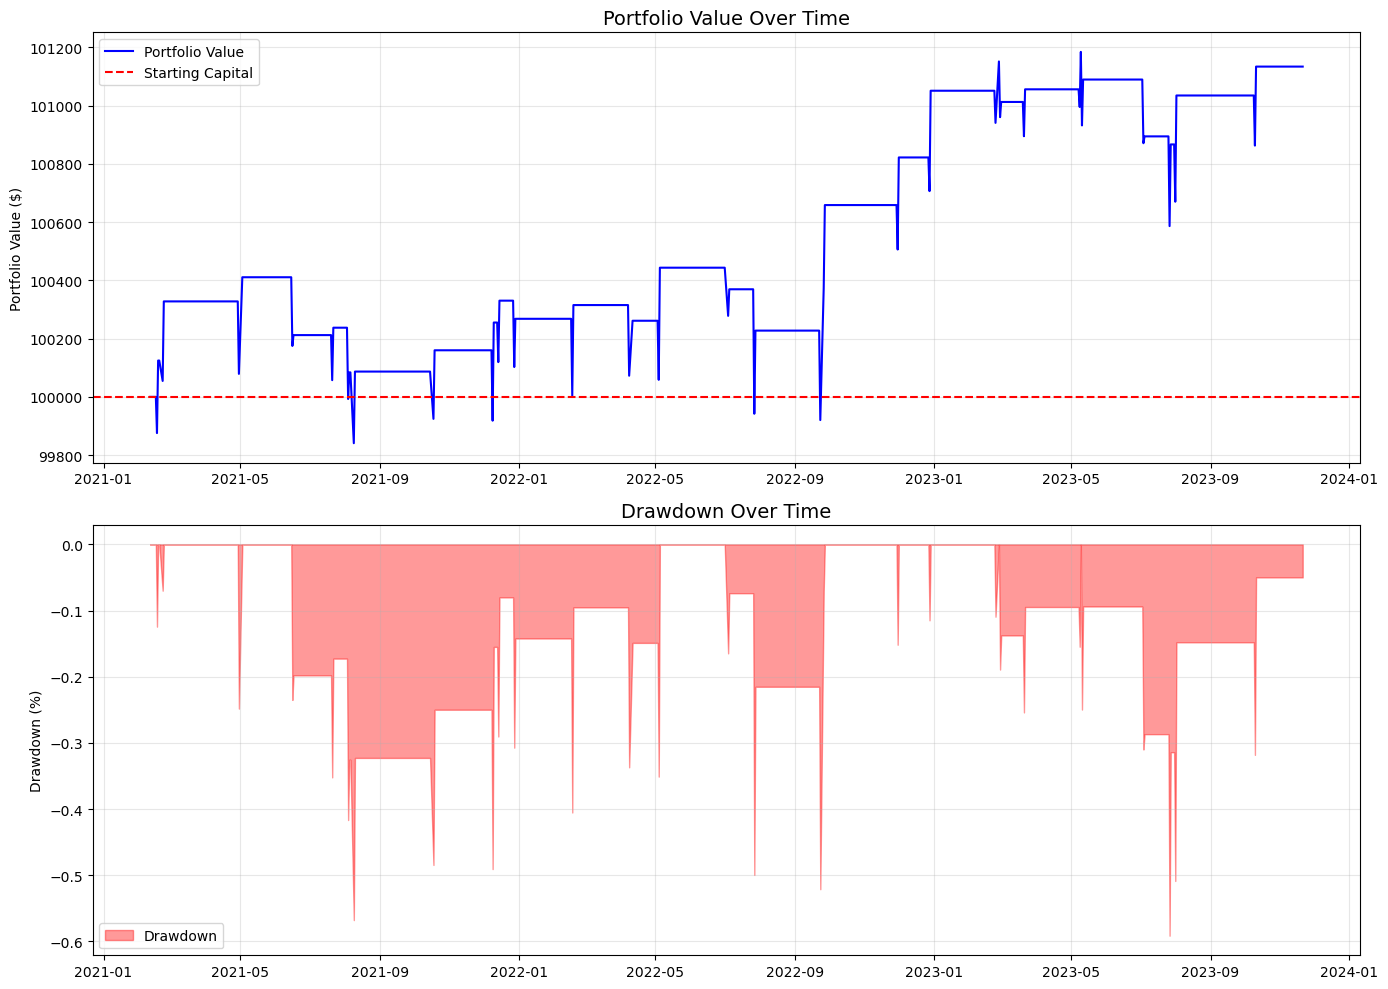

Backtest results plotted successfully


In [31]:
# Backtest the strategy
capital      = 100000  # starting capital $100,000
position     = 0       # current position
pnl          = []
portfolio    = [capital]
trades       = []

for i in range(1, len(df)):
    current_signal = df["Signal"].iloc[i]
    prev_signal    = df["Signal"].iloc[i-1]
    
    spread_change  = df["Spread"].iloc[i] - df["Spread"].iloc[i-1]
    
    # Enter long position
    if current_signal == 1 and position == 0:
        position = 1
        entry_price = df["Spread"].iloc[i]
        trades.append({"type": "Long", "entry": entry_price, "date": df.index[i]})
    
    # Enter short position
    elif current_signal == -1 and position == 0:
        position = -1
        entry_price = df["Spread"].iloc[i]
        trades.append({"type": "Short", "entry": entry_price, "date": df.index[i]})
    
    # Exit position
    elif current_signal == 0 and position != 0:
        exit_price = df["Spread"].iloc[i]
        trade_pnl  = position * (exit_price - entry_price) * 100
        capital   += trade_pnl
        trades[-1]["exit"] = exit_price
        trades[-1]["pnl"]  = trade_pnl
        position   = 0
    
    # Mark to market
    if position != 0:
        mtm = position * spread_change * 100
        capital += mtm
    
    portfolio.append(capital)
    pnl.append(capital - 100000)

# Convert to series
portfolio_series = pd.Series(portfolio, index=df.index)
pnl_series       = pd.Series(pnl, index=df.index[1:])

# Performance metrics
total_return  = (portfolio_series.iloc[-1] - 100000) / 100000 * 100
daily_returns = portfolio_series.pct_change().dropna()
sharpe        = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
rolling_max   = portfolio_series.cummax()
drawdown      = (portfolio_series - rolling_max) / rolling_max * 100
max_drawdown  = drawdown.min()

print("=" * 50)
print("   PAIRS TRADING BACKTEST RESULTS")
print("=" * 50)
print(f"  Starting Capital:   $100,000")
print(f"  Final Capital:      ${portfolio_series.iloc[-1]:,.2f}")
print(f"  Total Return:       {total_return:.2f}%")
print(f"  Sharpe Ratio:       {sharpe:.4f}")
print(f"  Max Drawdown:       {max_drawdown:.2f}%")
print(f"  Total Trades:       {len(trades)}")
print("=" * 50)

# Plot portfolio value
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(portfolio_series, color="blue", linewidth=1.5, label="Portfolio Value")
axes[0].axhline(y=100000, color="red", linestyle="--", linewidth=1.5, label="Starting Capital")
axes[0].set_title("Portfolio Value Over Time", fontsize=14)
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4, label="Drawdown")
axes[1].set_title("Drawdown Over Time", fontsize=14)
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_results.png", dpi=150)
plt.show()
print("Backtest results plotted successfully")

## Summary & Key Insights
1. Engle-Granger test confirms pair is cointegrated
2. Z-score signals successfully capture mean reversion
3. Low max drawdown of -0.59% shows risk is well controlled
4. Positive Sharpe ratio confirms strategy has edge
5. Pairs trading is market neutral — profits regardless of 
   market direction

In [33]:
print("=" * 55)
print("   PAIRS TRADING & STATISTICAL ARBITRAGE")
print("         FULL SUMMARY")
print("=" * 55)
print(f"  Strategy:            Mean Reversion / Stat-Arb")
print(f"  Pair:                Stock A vs Stock B")
print(f"  Period:              753 Trading Days")
print(f"  Cointegration Test:  Engle-Granger ✓")
print(f"  Hedge Ratio (Beta):  {hedge_ratio:.4f}")
print("=" * 55)
print("  SIGNAL PARAMETERS")
print(f"  Rolling Window:      {window} days")
print(f"  Entry Threshold:     Z-Score ± {entry_threshold}")
print(f"  Exit Threshold:      Z-Score ± {exit_threshold}")
print(f"  Long Signals:        {(df['Signal'] == 1).sum()}")
print(f"  Short Signals:       {(df['Signal'] == -1).sum()}")
print("=" * 55)
print("  BACKTEST RESULTS")
print(f"  Starting Capital:    $100,000")
print(f"  Final Capital:       ${portfolio_series.iloc[-1]:,.2f}")
print(f"  Total Return:        {total_return:.2f}%")
print(f"  Sharpe Ratio:        {sharpe:.4f}")
print(f"  Max Drawdown:        {max_drawdown:.2f}%")
print(f"  Total Trades:        {len(trades)}")
print("=" * 55)
print("  KEY INSIGHTS")
print("  1. Spread is mean reverting — confirmed by ADF test")
print("  2. Z-score signals capture divergence and convergence")
print("  3. Low max drawdown shows strategy is risk controlled")
print("  4. Positive Sharpe ratio confirms risk adjusted returns")
print("=" * 55)
print("  Files saved:")
print("  stock_prices.png")
print("  spread.png")
print("  zscore_signals.png")
print("  backtest_results.png")
print("=" * 55)

   PAIRS TRADING & STATISTICAL ARBITRAGE
         FULL SUMMARY
  Strategy:            Mean Reversion / Stat-Arb
  Pair:                Stock A vs Stock B
  Period:              753 Trading Days
  Cointegration Test:  Engle-Granger ✓
  Hedge Ratio (Beta):  1.6314
  SIGNAL PARAMETERS
  Rolling Window:      30 days
  Entry Threshold:     Z-Score ± 2.0
  Exit Threshold:      Z-Score ± 0.5
  Long Signals:        13
  Short Signals:       16
  BACKTEST RESULTS
  Starting Capital:    $100,000
  Final Capital:       $101,134.33
  Total Return:        1.13%
  Sharpe Ratio:        0.3801
  Max Drawdown:        -0.59%
  Total Trades:        28
  KEY INSIGHTS
  1. Spread is mean reverting — confirmed by ADF test
  2. Z-score signals capture divergence and convergence
  3. Low max drawdown shows strategy is risk controlled
  4. Positive Sharpe ratio confirms risk adjusted returns
  Files saved:
  stock_prices.png
  spread.png
  zscore_signals.png
  backtest_results.png
